In [1]:
Output = '/Users/alexis/Library/CloudStorage/OneDrive-UniversityofNorthCarolinaatChapelHill/CEMALB_DataAnalysisPM/Projects/P1015. Fire Sufficient Similarity/P1015.3. Analyses/P1015.3.4. Individual Visualizations/Output'
cur_date = '041126'

library(readxl)
library(tidyverse)
library(reshape2)
library(gtsummary)
library(ggpubr)
library(rstatix)
library(car)
library(rlang)

# reading in files
full_df = data.frame(read_excel("Input/Processed_Data_032426.xlsx")) %>%
    # removing records that weren't measured
    filter(Value2 == 'Present') %>%
    select(-Value2)
wf_info_df = data.frame(read_excel("Input/Study_Info_WF_012226.xlsx", sheet = 2))[,1:12]
ws_info_df = data.frame(read_excel("Input/Study_Info_WS_012226.xlsx", sheet = 2))[,1:15]
ws_info_df$HAWC_ID = as.character(ws_info_df$HAWC_ID)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths



Attaching package: ‘rstatix’


The following object is masked from ‘package:stats’:

    filter


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some



Attaching package: ‘rlang’


The following objects are masked from ‘package:purrr

In [2]:
head(full_df)
head(wf_info_df)
head(ws_info_df)

,HAWC_ID,Metric,Sample,Study,Sample_Number,Study_Sample_ID,DTXSID,Value,Class,Name
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>
1,1289889,Volume,WF,Scaramboni et al. 2024,3,1289889_3,Ca,8.59618976,Metal,Calcium
2,1289889,Volume,WF,Scaramboni et al. 2024,3,1289889_3,Ni,0.54649640,Metal,Nickel
3,1289889,Volume,WF,Scaramboni et al. 2024,3,1289889_3,DTXSID2020139,0.12565110,PAH,Benzo(a)pyrene
4,1289889,Volume,WF,Scaramboni et al. 2024,3,1289889_3,DTXSID0022432,0.07997538,PAH,Chrysene
5,1289889,Volume,WF,Scaramboni et al. 2024,3,1289889_3,DTXSID8024153,0.10165008,PAH,"Indeno(1,2,3-cd)pyrene"
6,1289889,Volume,WF,Scaramboni et al. 2024,3,1289889_3,DTXSID3024104,0.15574923,PAH,Fluoranthene


,HAWC_ID,Study,Sample_Number,Study_Sample_ID,Class,Metric,Fire_Type,Location,PM_Size,Sample_Matrix,Fuel_Species,Fuel_Type
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1289737,Campbell et al. 2024,1,1289737_1,PAH,Weight,Natural,Wooded,NA,Ash,Eucalyptus,Hardwood
2,1289739,Campos et al. 2019,1,1289739_1,PAH,Weight,Natural,Wooded,NA,Ash,Eucalyptus,Hardwood
3,1289739,Campos et al. 2019,2,1289739_2,PAH,Weight,Natural,Wooded,NA,Ash,Eucalyptus,Hardwood
4,1289739,Campos et al. 2019,3,1289739_3,PAH,Weight,Natural,Wooded,NA,Ash,Eucalyptus,Hardwood
5,1289739,Campos et al. 2019,4,1289739_4,PAH,Weight,Natural,Wooded,NA,Ash,Eucalyptus,Hardwood
6,1289739,Campos et al. 2019,5,1289739_5,PAH,Weight,Natural,Wooded,NA,Ash,Pine,Softwood


,HAWC_ID,Study,Sample_Number,Study_Sample_ID,Class,Metric,Source,Combustion_Condition,PM_Size,Sample_Matrix,Fuel_Species,Sample_Origin,Fuel_Type,Efficiency,Fuel_Size
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,429174,Arif et al. 2017,1,429174_1,PAH,Weight,Boiler,NA,Very fine,PM,Mixed,Smoke,Softwood,Medium,Chip
2,429174,Arif et al. 2017,2,429174_2,PAH,Weight,Boiler,NA,Very fine,PM,Beech,Smoke,Hardwood,Medium,Chip
3,298566,Jalava et al. 2010,1,298566_1,PAH,Weight,Masonry heater,Normal,Very fine,PM,Birch,Flue gas,Hardwood,Medium,Log
4,298566,Jalava et al. 2010,2,298566_2,PAH,Weight,Masonry heater,Normal,Very fine,PM,Birch,Flue gas,Hardwood,Medium,Log
5,298566,Jalava et al. 2010,3,298566_3,PAH,Weight,Masonry heater,Smoldering,Very fine,PM,Birch,Flue gas,Hardwood,Medium,Log
6,298566,Jalava et al. 2010,4,298566_4,PAH,Weight,Masonry heater,Smoldering,Very fine,PM,Birch,Flue gas,Hardwood,Medium,Log


Using boxplots to visualize statistically significant metals/chemicals between woodsmoke and wildfire samples.

In [3]:
# creating 1 df that contains all the meta data
ws_info_df = ws_info_df %>%
    mutate(Sample = 'WS', Fire_Type = NA, Location = NA)
wf_info_df = wf_info_df %>%
    mutate(Sample = 'WF', Source = NA, Combustion_Condition = NA, Sample_Origin = NA, Efficiency = NA, Fuel_Size = NA) 
wf_info_df = wf_info_df[,colnames(ws_info_df)]

info_df = rbind(wf_info_df, ws_info_df) %>%
    # consolidating some of the data
    mutate(PM_Size = ifelse(PM_Size == 'Very coarse', "Coarse", 
                            ifelse(PM_Size == 'Very fine', "Fine", PM_Size)))
head(info_df)

,HAWC_ID,Study,Sample_Number,Study_Sample_ID,Class,Metric,Source,Combustion_Condition,PM_Size,Sample_Matrix,Fuel_Species,Sample_Origin,Fuel_Type,Efficiency,Fuel_Size,Sample,Fire_Type,Location
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1289737,Campbell et al. 2024,1,1289737_1,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
2,1289739,Campos et al. 2019,1,1289739_1,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
3,1289739,Campos et al. 2019,2,1289739_2,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
4,1289739,Campos et al. 2019,3,1289739_3,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
5,1289739,Campos et al. 2019,4,1289739_4,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
6,1289739,Campos et al. 2019,5,1289739_5,PAH,Weight,NA,NA,NA,Ash,Pine,NA,Softwood,NA,NA,WF,Natural,Wooded


In [4]:
# splitting based on metric
metric_split = full_df %>%
    group_by(Metric) %>%
    group_split()

vol_df = metric_split[[1]]
weight_df = metric_split[[2]]

In [5]:
# converting to a wide format
wider_vol_df = vol_df %>%
    select(-c("DTXSID", "Class")) %>%
    # removing outliers
    #filter(SampleID %notin% vol_outliers) %>%
    pivot_wider(names_from = Name, values_from = Value) %>%
    column_to_rownames(var = "Study_Sample_ID")

wider_weight_df = weight_df %>%
    select(-c("DTXSID", "Class")) %>%
    pivot_wider(names_from = Name, values_from = Value) %>%
    column_to_rownames(var = "Study_Sample_ID")

head(wider_vol_df)

,HAWC_ID,Metric,Sample,Study,Sample_Number,Calcium,Nickel,Benzo(a)pyrene,Chrysene,"Indeno(1,2,3-cd)pyrene",⋯,Phenanthrene,Copper,Lead,Benzo(GHI)perylene,Iron,Potassium,Manganese,Pyrene,Strontium,Zinc
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1289889_3,1289889,Volume,WF,Scaramboni et al. 2024,3,8.596190,0.5464964,0.1256511,0.07997538,0.10165008,⋯,0.0772430,6.781360,0.8718436,0.214124805,7.247928,9.491853,1.448901,0.1123665,NA,NA
1289889_1,1289889,Volume,WF,Scaramboni et al. 2024,1,2.931926,0.6959938,0.9568001,0.40925515,1.00647756,⋯,0.2116353,6.221104,2.9164766,1.572404647,9.609179,9.612868,3.666757,0.5300707,NA,NA
1289889_2,1289889,Volume,WF,Scaramboni et al. 2024,2,2.931926,0.2986583,0.5607150,0.30451104,0.49159659,⋯,0.1137005,4.887525,2.0426443,1.261229909,8.629357,9.459432,2.558268,0.3459640,NA,NA
1426391_1,1426391,Volume,WF,O'Malley et al. 2024,1,NA,NA,0.1953476,0.64800518,0.04474382,⋯,5.1043367,NA,NA,0.073408955,NA,NA,NA,3.0959244,NA,NA
1426391_2,1426391,Volume,WF,O'Malley et al. 2024,2,NA,NA,0.4419814,0.08224829,0.01876099,⋯,2.0391384,NA,NA,0.002032767,NA,NA,NA,0.5048746,NA,NA
1426391_3,1426391,Volume,WF,O'Malley et al. 2024,3,NA,NA,0.4419814,0.01409816,0.01876099,⋯,1.7268312,NA,NA,0.001026833,NA,NA,NA,0.2326608,NA,NA


## Assessing Distributions

In [6]:
# gives number of samples
table(wider_vol_df$Sample)
table(wider_weight_df$Sample)


WF WS 
57  5 


WF WS 
47 63 

Now assessing normality of the constituents using a shapiro wilk test.

In [7]:
# using a shapiro wilk test to assess normality
do.call(rbind.data.frame, apply(wider_vol_df[,6:21], 2, shapiro.test))[,1:3] %>%
    # adding a column that clarifies whether or not a variable is normally distributed or not
    mutate(Normality = ifelse(p.value < 0.05, "Non-normal", "Normal"))

do.call(rbind.data.frame, apply(wider_weight_df[,6:21], 2, shapiro.test))[,1:3] %>%
    mutate(Normality = ifelse(p.value < 0.05, "Non-normal", "Normal"))

,statistic,p.value,method,Normality
,<dbl>,<dbl>,<chr>,<chr>
Calcium,0.7717153,9.316419e-07,Shapiro-Wilk normality test,Non-normal
Nickel,0.9369061,4.072940e-02,Shapiro-Wilk normality test,Non-normal
Benzo(a)pyrene,0.5935367,7.669454e-07,Shapiro-Wilk normality test,Non-normal
Chrysene,0.5970592,3.945072e-07,Shapiro-Wilk normality test,Non-normal
"Indeno(1,2,3-cd)pyrene",0.4126159,2.188739e-08,Shapiro-Wilk normality test,Non-normal
Fluoranthene,0.5701895,1.364042e-07,Shapiro-Wilk normality test,Non-normal
Phenanthrene,0.6203214,5.114758e-07,Shapiro-Wilk normality test,Non-normal
Copper,0.9725888,4.492248e-01,Shapiro-Wilk normality test,Normal
Lead,0.9663041,2.872770e-01,Shapiro-Wilk normality test,Normal


,statistic,p.value,method,Normality
,<dbl>,<dbl>,<chr>,<chr>
Chromium,0.8733163,4.470792e-05,Shapiro-Wilk normality test,Non-normal
Manganese,0.9221610,8.425967e-04,Shapiro-Wilk normality test,Non-normal
Lead,0.9539853,2.084287e-02,Shapiro-Wilk normality test,Non-normal
Calcium,0.8233161,1.763929e-05,Shapiro-Wilk normality test,Non-normal
Copper,0.9648356,9.087749e-02,Shapiro-Wilk normality test,Normal
Iron,0.9428595,3.286924e-02,Shapiro-Wilk normality test,Non-normal
Nickel,0.9409285,1.607267e-02,Shapiro-Wilk normality test,Non-normal
Zinc,0.9636056,5.000739e-02,Shapiro-Wilk normality test,Normal
Anthracene,0.8401915,6.127408e-07,Shapiro-Wilk normality test,Non-normal


Most variables aren't normally distributed, even though we performed a psuedo log~2~ transformation to help with this.

## Summary Statistics

In [8]:
# combining meta data and concentration data
full_vol_df = wider_vol_df %>%
    rownames_to_column(var = "Study_Sample_ID") %>%
    left_join(info_df[,c(4,6,9:11,13,16:18)]) %>%
    select(-Metric) %>%
    unique() %>%
    remove_rownames() %>%
    column_to_rownames(var = "Study_Sample_ID") %>%
    mutate(Sample = ifelse(Sample == "WS", "Woodsmoke",
                                  ifelse(Sample == "WF", "Wildfire", Sample)))

# removing some ids that were causing issues..
removed_id_df = info_df %>%
    filter(Study_Sample_ID == '1289922_1' & Location == 'Wooded' |
    Study_Sample_ID == '981013_2' & PM_Size == 'Very fine')

info_df2 = anti_join(info_df, removed_id_df)

full_weight_df = wider_weight_df %>%
    rownames_to_column(var = "Study_Sample_ID") %>%
    left_join(info_df2[,c(4,6,9:11,13,16:18)]) %>%
    select(-Metric) %>%
    unique() %>%
    remove_rownames() %>%
    column_to_rownames(var = "Study_Sample_ID") %>%
    mutate(Sample = ifelse(Sample == "WS", "Woodsmoke",
                                  ifelse(Sample == "WF", "Wildfire", Sample)))

head(full_vol_df)

Joining with `by = join_by(Study_Sample_ID, Metric, Sample)`
Joining with `by = join_by(HAWC_ID, Study, Sample_Number, Study_Sample_ID,
Class, Metric, Source, Combustion_Condition, PM_Size, Sample_Matrix,
Fuel_Species, Sample_Origin, Fuel_Type, Efficiency, Fuel_Size, Sample,
Fire_Type, Location)`
Joining with `by = join_by(Study_Sample_ID, Metric, Sample)`


,HAWC_ID,Sample,Study,Sample_Number,Calcium,Nickel,Benzo(a)pyrene,Chrysene,"Indeno(1,2,3-cd)pyrene",Fluoranthene,⋯,Manganese,Pyrene,Strontium,Zinc,PM_Size,Sample_Matrix,Fuel_Species,Fuel_Type,Fire_Type,Location
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1289889_3,1289889,Wildfire,Scaramboni et al. 2024,3,8.596190,0.5464964,0.1256511,0.07997538,0.10165008,0.1557492,⋯,1.448901,0.1123665,NA,NA,Fine,Air,NA,NA,Natural,Urban and wooded
1289889_1,1289889,Wildfire,Scaramboni et al. 2024,1,2.931926,0.6959938,0.9568001,0.40925515,1.00647756,0.5350576,⋯,3.666757,0.5300707,NA,NA,Fine,Air,NA,NA,Natural,Urban and wooded
1289889_2,1289889,Wildfire,Scaramboni et al. 2024,2,2.931926,0.2986583,0.5607150,0.30451104,0.49159659,0.3010023,⋯,2.558268,0.3459640,NA,NA,Fine,Air,NA,NA,Natural,Urban and wooded
1426391_1,1426391,Wildfire,O'Malley et al. 2024,1,NA,NA,0.1953476,0.64800518,0.04474382,2.1890338,⋯,NA,3.0959244,NA,NA,Fine,Air,NA,NA,Natural,Urban and wooded
1426391_2,1426391,Wildfire,O'Malley et al. 2024,2,NA,NA,0.4419814,0.08224829,0.01876099,0.4005379,⋯,NA,0.5048746,NA,NA,Fine,Air,NA,NA,Natural,Urban and wooded
1426391_3,1426391,Wildfire,O'Malley et al. 2024,3,NA,NA,0.4419814,0.01409816,0.01876099,0.2785796,⋯,NA,0.2326608,NA,NA,Fine,Air,NA,NA,Natural,Urban and wooded


In [9]:
full_vol_df %>%
    tbl_summary(by = Sample, missing = "no", 
    include = colnames(full_vol_df[5:24]), 
              statistic = list(all_continuous() ~ "{mean} ({sd})",
                               all_categorical() ~ "{n} ({p}%)")) %>%
    add_n() %>% 
    #add_overall() %>%
    add_p(test = list(all_continuous() ~ "wilcox.test",
                    all_categorical() ~ "chisq.test")) %>% # adding p value from chi square
    as_tibble()

The following warnings were returned during `add_p()`:
! For variable `Benzo(GHI)perylene` (`Sample`) and "estimate", "statistic",
  "p.value", "conf.low", and "conf.high" statistics: cannot compute exact
  p-value with ties
! For variable `Benzo(GHI)perylene` (`Sample`) and "estimate", "statistic",
  "p.value", "conf.low", and "conf.high" statistics: cannot compute exact
  confidence intervals with ties
! For variable `Benzo(a)pyrene` (`Sample`) and "estimate", "statistic",
  "p.value", "conf.low", and "conf.high" statistics: cannot compute exact
  p-value with ties
! For variable `Benzo(a)pyrene` (`Sample`) and "estimate", "statistic",
  "p.value", "conf.low", and "conf.high" statistics: cannot compute exact
  confidence intervals with ties
! For variable `Calcium` (`Sample`) and "estimate", "statistic", "p.value",
  "conf.low", and "conf.high" statistics: cannot compute exact p-value with
  ties
! For variable `Calcium` (`Sample`) and "estimate", "statistic", "p.value",
  "conf.low"

**Characteristic**,**N**,**Wildfire** N = 57,**Woodsmoke** N = 5,**p-value**
<chr>,<chr>,<chr>,<chr>,<chr>
Calcium,43,15.0 (4.7),17.8 (1.4),0.2
Nickel,36,5.6 (2.7),11.2 (1.1),0.025
Benzo(a)pyrene,23,0.6 (0.7),16.9 (1.0),<0.001
Chrysene,25,0.7 (0.8),17.7 (2.5),<0.001
"Indeno(1,2,3-cd)pyrene",22,0.3 (0.4),14.1 (1.1),0.026
Fluoranthene,26,0.7 (0.9),19.7 (0.8),<0.001
Phenanthrene,26,1 (2),22 (1),<0.001
Copper,39,7.38 (2.28),13.45 (0.15),0.020
Lead,39,6.3 (2.4),13.5 (1.2),0.005


In [10]:
full_weight_df %>%
    tbl_summary(by = Sample, missing = "no", 
    include = colnames(full_weight_df[5:24]), 
              statistic = list(all_continuous() ~ "{mean} ({sd})",
                               all_categorical() ~ "{n} ({p}%)")) %>%
    add_n() %>% 
    #add_overall() %>%
    add_p(test = list(all_continuous() ~ "wilcox.test",
                    all_categorical() ~ "chisq.test")) %>% # adding p value from chi square
    as_tibble()

The following warnings were returned during `add_p()`:
! For variable `Acenaphthylene` (`Sample`) and "estimate", "statistic",
  "p.value", "conf.low", and "conf.high" statistics: cannot compute exact
  p-value with ties
! For variable `Acenaphthylene` (`Sample`) and "estimate", "statistic",
  "p.value", "conf.low", and "conf.high" statistics: cannot compute exact
  confidence intervals with ties
! For variable `Anthracene` (`Sample`) and "estimate", "statistic", "p.value",
  "conf.low", and "conf.high" statistics: cannot compute exact p-value with
  ties
! For variable `Anthracene` (`Sample`) and "estimate", "statistic", "p.value",
  "conf.low", and "conf.high" statistics: cannot compute exact confidence
  intervals with ties
! For variable `Cadmium` (`Sample`) and "estimate", "statistic", "p.value",
  "conf.low", and "conf.high" statistics: cannot compute exact p-value with
  ties
! For variable `Cadmium` (`Sample`) and "estimate", "statistic", "p.value",
  "conf.low", and "conf.high

**Characteristic**,**N**,**Wildfire** N = 47,**Woodsmoke** N = 63,**p-value**
<chr>,<chr>,<chr>,<chr>,<chr>
Chromium,53,5.32 (2.90),3.85 (2.87),0.049
Manganese,61,9.2 (1.7),5.6 (3.8),<0.001
Lead,62,4.88 (1.73),4.06 (3.01),0.15
Calcium,41,15.6 (2.0),10.2 (4.6),<0.001
Copper,58,6.62 (3.14),5.39 (3.09),0.3
Iron,43,12.3 (2.4),7.4 (4.2),<0.001
Nickel,49,5.21 (1.44),4.03 (3.08),0.082
Zinc,66,8.62 (2.38),10.08 (3.32),0.003
Anthracene,66,0.10 (0.26),4.24 (3.14),<0.001


## Statistical Tests

In [11]:
# unique(long_vol_df$`Sample_Matrix-Sample`)
# unique(long_vol_df$`Fuel_Type-Sample`)
# unique(long_weight_df$`Sample_Matrix-Sample`)
# unique(long_weight_df$`Fuel_Type-Sample`)

In [12]:
long_vol_df = full_vol_df %>%
    pivot_longer(cols = 5:20, names_to = "Name", values_to = "Value") %>%
    unite(`Sample_Matrix-Sample`, Sample_Matrix, Sample, sep = "-", remove = FALSE) %>%
    # consolidating some of the classes with small sample sizes
     mutate(`Sample_Matrix-Sample` = ifelse(grepl("Smoke-", `Sample_Matrix-Sample`), "Other-WF", 
                            ifelse(grepl('Aerosol',`Sample_Matrix-Sample`), "Other-WF", `Sample_Matrix-Sample`))) %>%
    unite(`Fuel_Type-Sample`, Fuel_Type, Sample, sep = "-", remove = FALSE) %>%
    rename(Sample_Matrix_Sample = `Sample_Matrix-Sample`, Fuel_Type_Sample = `Fuel_Type-Sample`)

long_weight_df = full_weight_df %>%
    pivot_longer(cols = 5:20, names_to = "Name", values_to = "Value") %>%
    unite(`Sample_Matrix-Sample`, Sample_Matrix, Sample, sep = "-", remove = FALSE) %>%
    unite(`Fuel_Type-Sample`, Fuel_Type, Sample, sep = "-", remove = FALSE) %>%
    rename(Sample_Matrix_Sample = `Sample_Matrix-Sample`, Fuel_Type_Sample = `Fuel_Type-Sample`)

# converting into factors
long_vol_df$`Sample_Matrix_Sample` = factor(long_vol_df$`Sample_Matrix_Sample`, levels = c('Other-WF', 
                                            'Air-Wildfire', 'Smoke-Wildfire', 'PM-Woodsmoke', 'PM-Wildfire'))
long_vol_df$`Fuel_Type_Sample` = factor(long_vol_df$`Fuel_Type_Sample`)
long_weight_df$`Sample_Matrix_Sample` = factor(long_weight_df$`Sample_Matrix_Sample`, levels = c('NA-Woodsmoke', 
                                            'PM-Woodsmoke', 'PM-Wildfire', 'Sediment-Wildfire', 'Ash-Wildfire'))
long_weight_df$`Fuel_Type_Sample` = factor(long_weight_df$`Fuel_Type_Sample`, levels = c('NA-Woodsmoke','NA-Wildfire',
                                                    'Mixed-Wildfire', 'Softwood-Woodsmoke', 'Hardwood-Woodsmoke', 
                                                    'Softwood-Wildfire', 'Hardwood-Wildfire'))

head(long_vol_df)

HAWC_ID,Sample_Matrix_Sample,Fuel_Type_Sample,Sample,Study,Sample_Number,PM_Size,Sample_Matrix,Fuel_Species,Fuel_Type,Fire_Type,Location,Name,Value
<chr>,<fct>,<fct>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
1289889,Air-Wildfire,NA-Wildfire,Wildfire,Scaramboni et al. 2024,3,Fine,Air,NA,NA,Natural,Urban and wooded,Calcium,8.59618976
1289889,Air-Wildfire,NA-Wildfire,Wildfire,Scaramboni et al. 2024,3,Fine,Air,NA,NA,Natural,Urban and wooded,Nickel,0.54649640
1289889,Air-Wildfire,NA-Wildfire,Wildfire,Scaramboni et al. 2024,3,Fine,Air,NA,NA,Natural,Urban and wooded,Benzo(a)pyrene,0.12565110
1289889,Air-Wildfire,NA-Wildfire,Wildfire,Scaramboni et al. 2024,3,Fine,Air,NA,NA,Natural,Urban and wooded,Chrysene,0.07997538
1289889,Air-Wildfire,NA-Wildfire,Wildfire,Scaramboni et al. 2024,3,Fine,Air,NA,NA,Natural,Urban and wooded,"Indeno(1,2,3-cd)pyrene",0.10165008
1289889,Air-Wildfire,NA-Wildfire,Wildfire,Scaramboni et al. 2024,3,Fine,Air,NA,NA,Natural,Urban and wooded,Fluoranthene,0.15574923


In [13]:
# running wilcox tests
sample_test_vol = long_vol_df %>%
    group_by(Name) %>%
    wilcox_test(Value ~ Sample) %>%
    add_significance(cutpoints = c(0, 1e-04, 0.001, 0.01, 0.05, 1),
                    symbols = c("****", "***", "**", "*", "ns")) %>%
    # manually adding the y position
    mutate(y.position = c(20, 20, 1.4, 23, 17, 23, 18, 20, 17, 20, 17, 24, 23, 23, 15, 22))

sample_test_weight = long_weight_df %>%
    group_by(Name) %>%
    wilcox_test(Value ~ Sample) %>%
    add_significance(cutpoints = c(0, 1e-04, 0.001, 0.01, 0.05, 1),
                    symbols = c("****", "***", "**", "*", "ns")) %>%
    # manually adding the y position
    mutate(y.position = c(14, 14, 14, 10, 19, 19, 18, 15, 14, 19, 17, 16, 23, 16, 16, 17))

head(sample_test_vol)

Name,.y.,group1,group2,n1,n2,statistic,p,p.signif,y.position
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<dbl>
Benzo(GHI)perylene,Value,Wildfire,Woodsmoke,20,4,0,0.002200,**,20.0
Benzo(a)pyrene,Value,Wildfire,Woodsmoke,18,5,0,0.000887,***,20.0
Calcium,Value,Wildfire,Woodsmoke,39,4,46,0.188000,ns,1.4
Chrysene,Value,Wildfire,Woodsmoke,20,5,0,0.000762,***,23.0
Copper,Value,Wildfire,Woodsmoke,37,2,0,0.020000,*,17.0
Fluoranthene,Value,Wildfire,Woodsmoke,21,5,0,0.000711,***,23.0


Warning message:
“Removed 449 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 449 rows containing missing values or values outside the scale range
(`geom_point()`).”


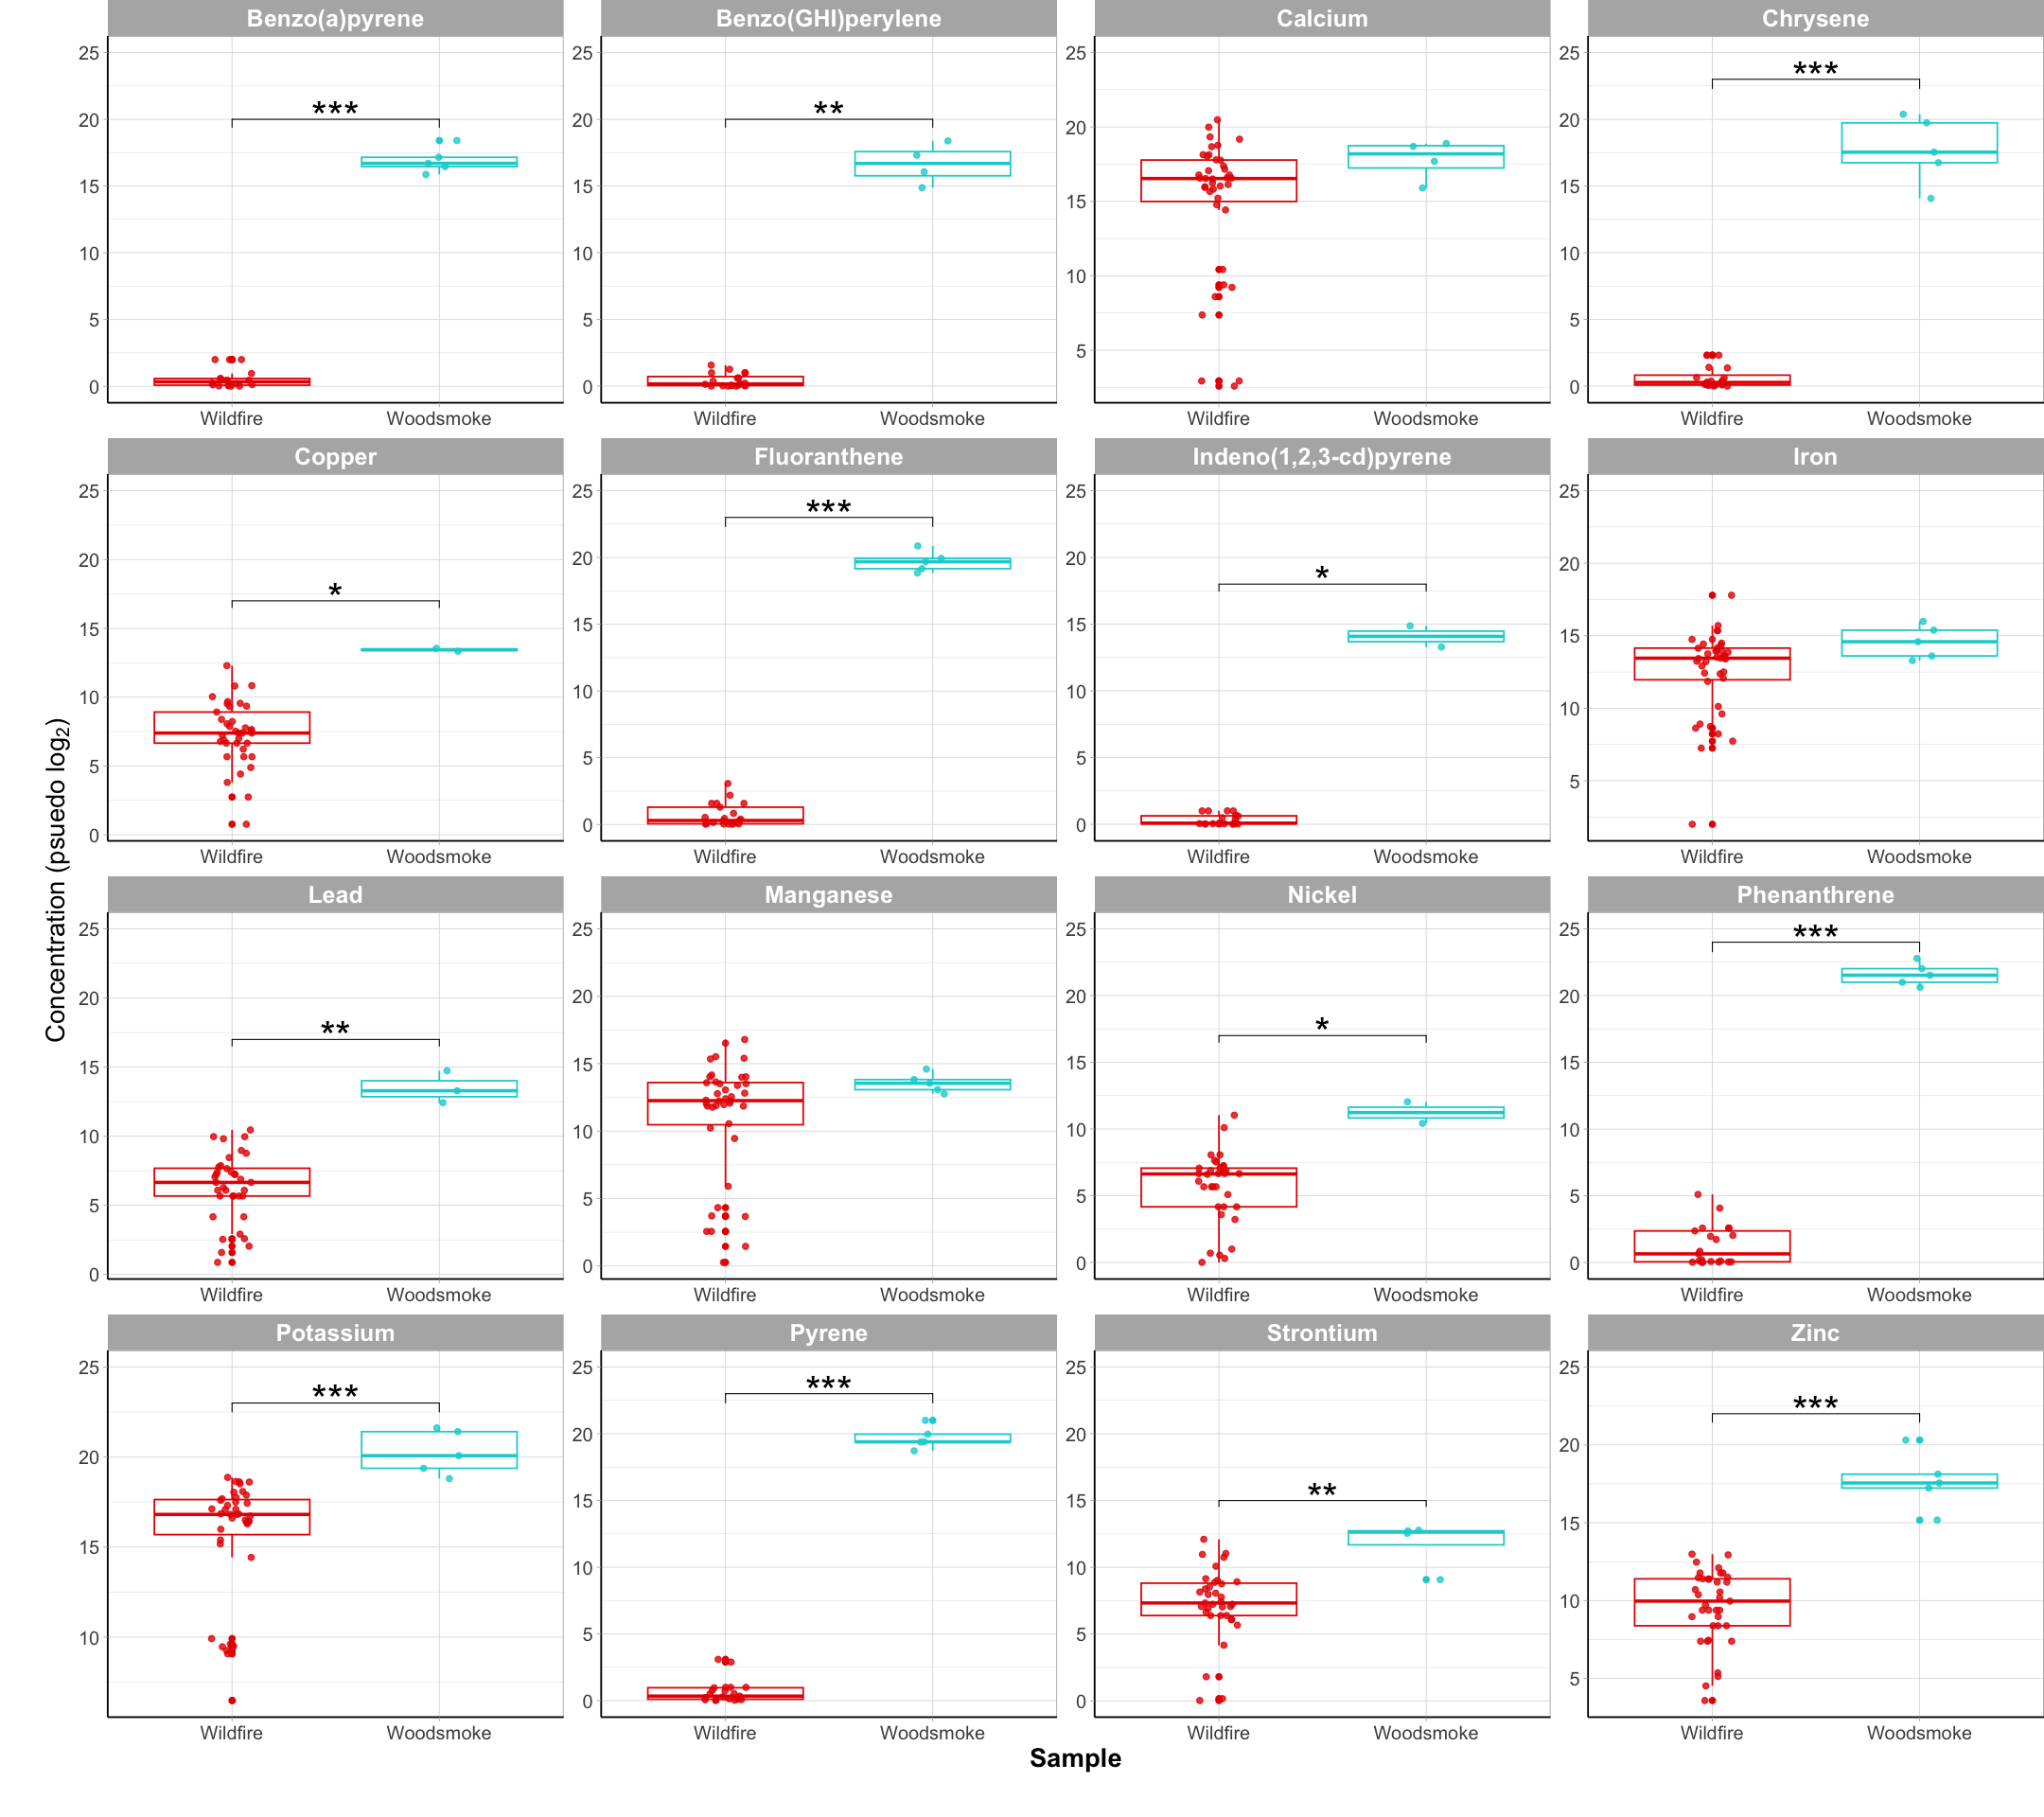

In [14]:
options(repr.plot.width=18, repr.plot.height=16) #changing size

vol_boxplots = ggplot(data = long_vol_df, aes(x = Sample, y = Value, color = Sample)) + 
  geom_boxplot() + 
  geom_point(position = position_jitter(w = 0.1), alpha = 0.8) + 
  ylim(NA, 25) + # adding more space for p value significance

  # Adding a p value from a Wilcoxon test
  stat_pvalue_manual(sample_test_vol %>%
                         filter(p.signif != 'ns'), label = "p.signif", size = 9) +


  facet_wrap(~Name, scales = 'free') +  

  theme_light() + 
  theme(axis.line = element_line(colour = "black"), #making x and y axes black
        axis.text = element_text(size = 12), #changing size of x axis labels
        legend.position = 'none', # removes legend
        plot.margin = unit(c(0,0,2,2), "lines"), # adding space at the bottom of the figure
        axis.title = element_text(face = "bold", size = rel(1.5)),
        strip.text.x = element_text(size = 15, face = "bold"), #changes size of facet x axis 
        strip.text.y = element_text(size = 15, face = "bold")) + #changes axis titles

  labs(y = expression("Concentration (psuedo "*log[2]*") ")) + #changing axis labels 
  scale_color_manual(values = c('#e60000', '#00d2d2'))

vol_boxplots

Warning message:
“Removed 816 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 816 rows containing missing values or values outside the scale range
(`geom_point()`).”


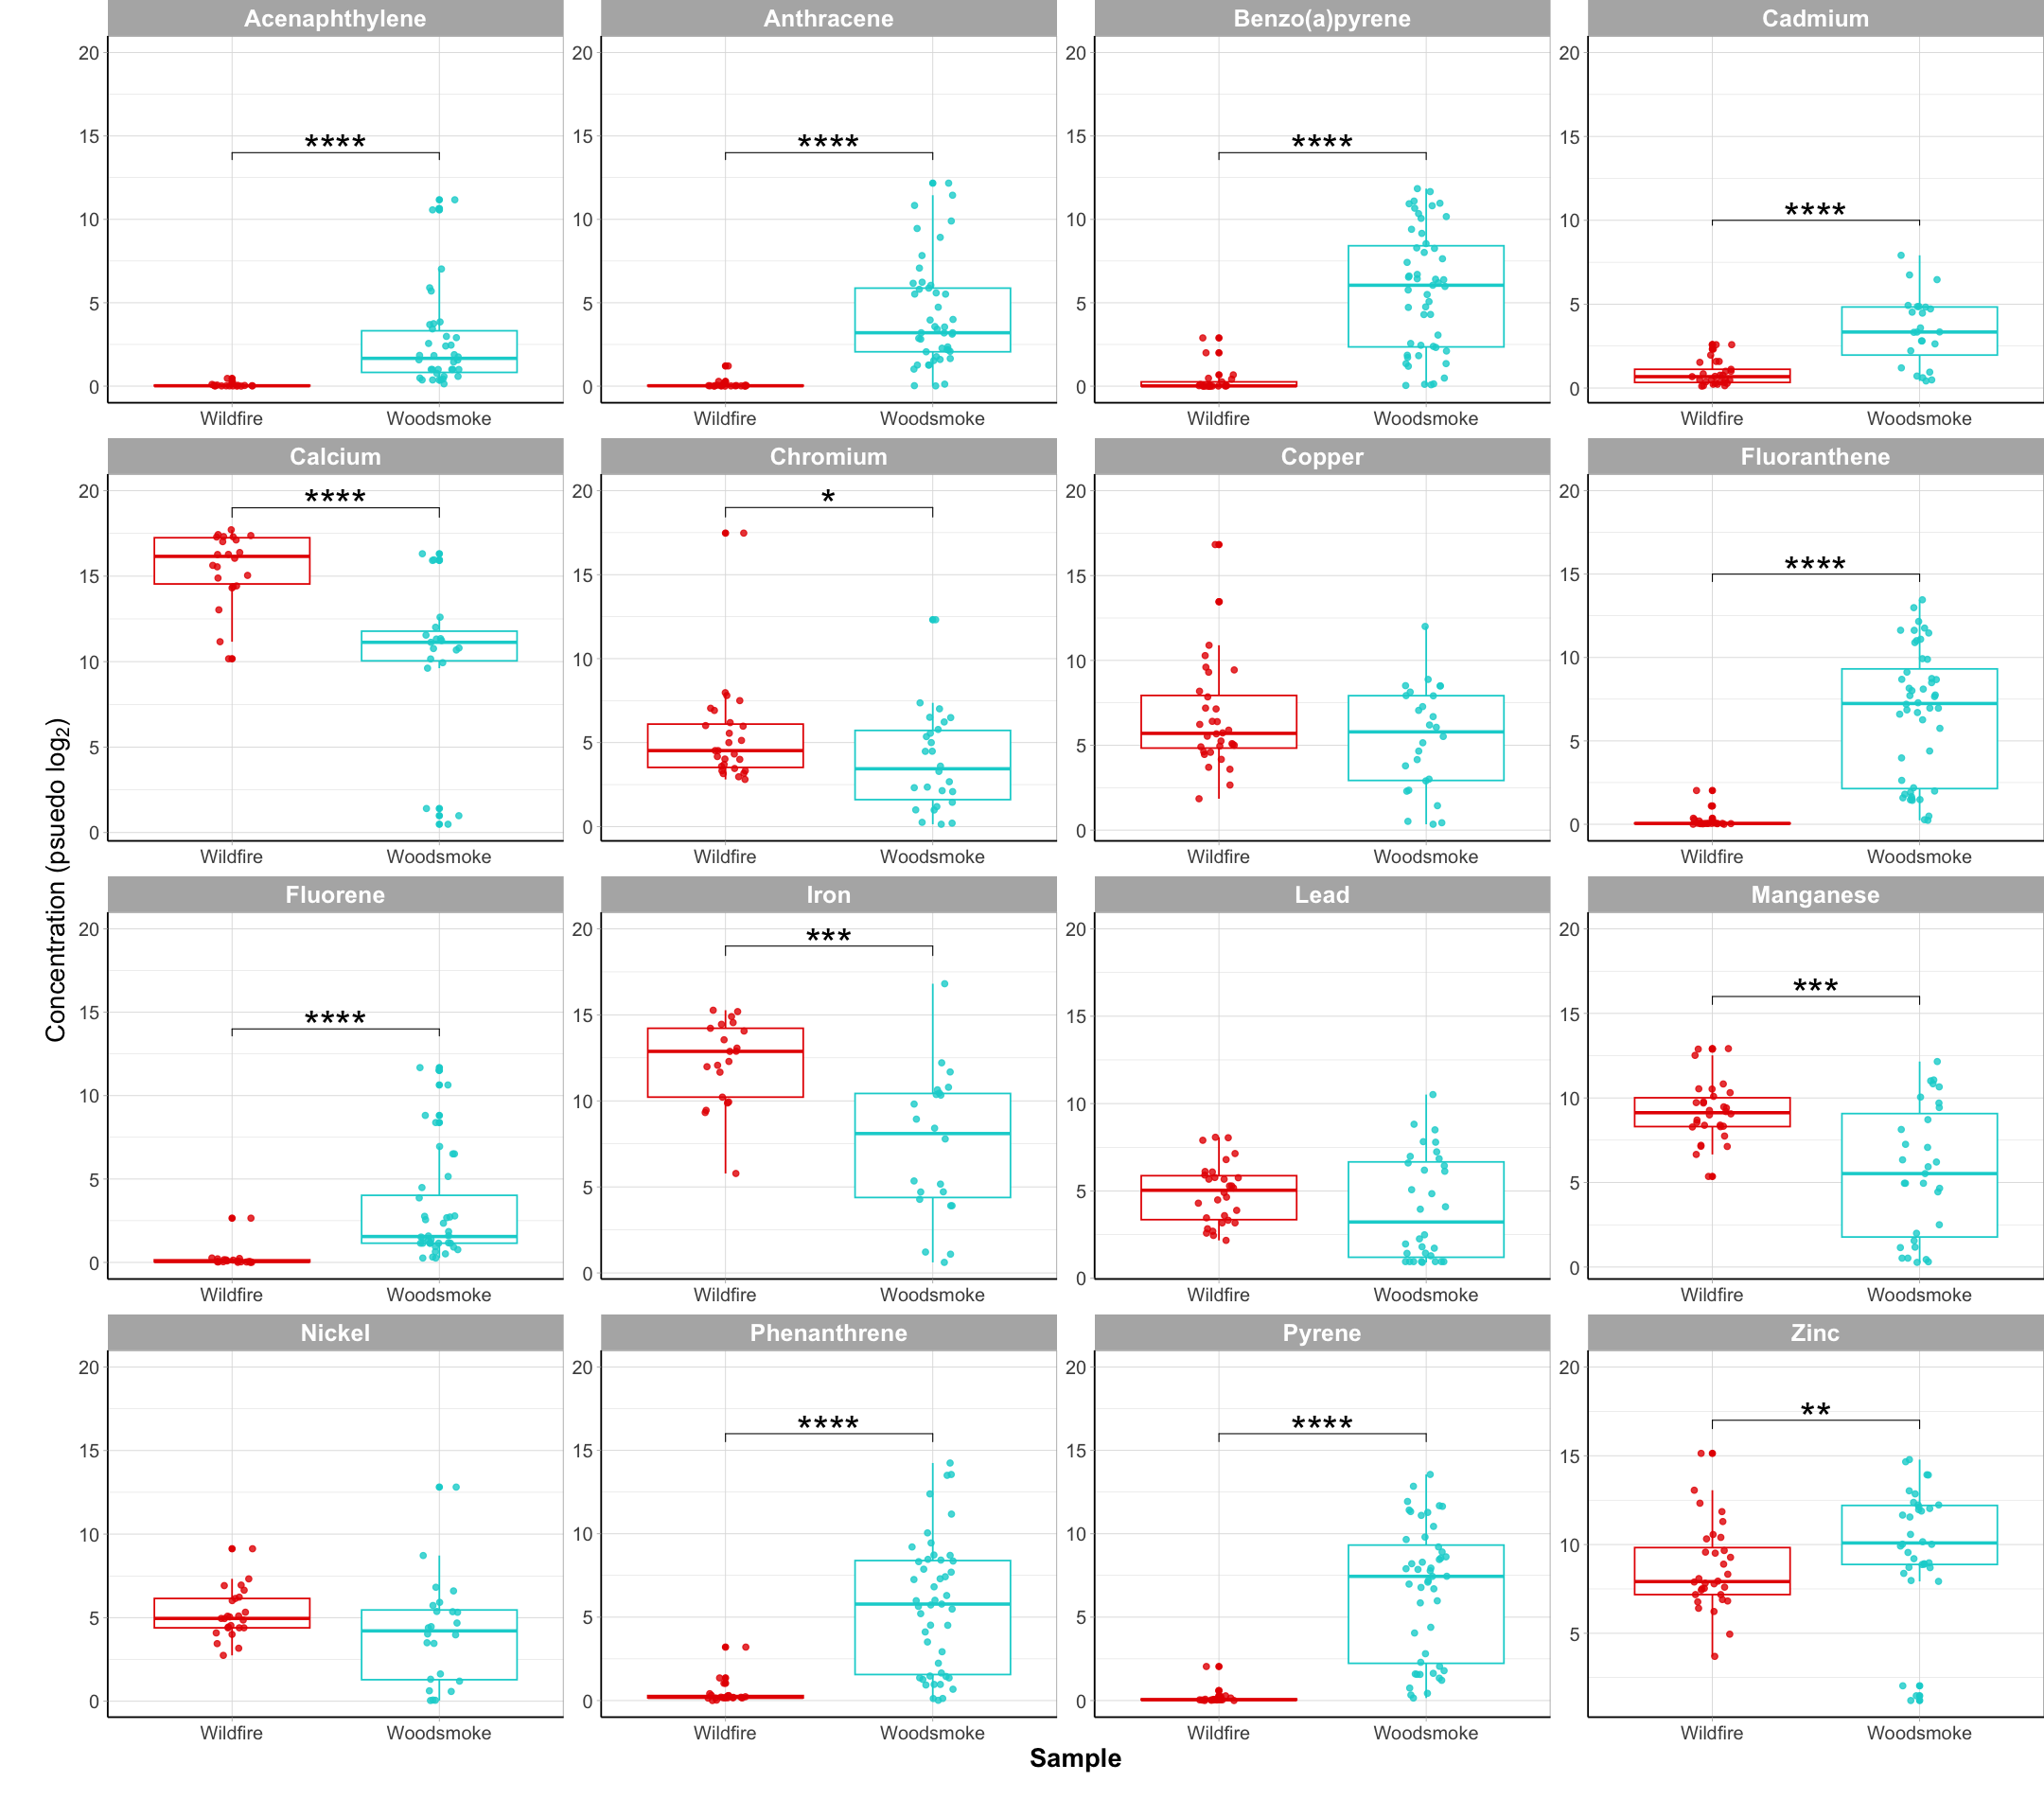

In [15]:
weight_boxplots = ggplot(data = long_weight_df, aes(x = Sample, y = Value, color = Sample)) + 
  geom_boxplot() + 
  geom_point(position = position_jitter(w = 0.1), alpha = 0.8) + 
  ylim(NA, 20) + # adding more space for p value significance

  # Adding a p value from a Wilcoxon test
  stat_pvalue_manual(sample_test_weight %>%
                         filter(p.signif != 'ns'), label = "p.signif", size = 9) +


  facet_wrap(~Name, scales = 'free') +  

  theme_light() + 
  theme(axis.line = element_line(colour = "black"), #making x and y axes black
        axis.text = element_text(size = 12), #changing size of x axis labels
        legend.position = 'none', # removes legend
        plot.margin = unit(c(0,0,2,2), "lines"), # adding space at the bottom of the figure
        axis.title = element_text(face = "bold", size = rel(1.5)),
        strip.text.x = element_text(size = 15, face = "bold"), #changes size of facet x axis 
        strip.text.y = element_text(size = 15, face = "bold")) + #changes axis titles

  labs(y = expression("Concentration (psuedo "*log[2]*") ")) + #changing axis labels 
  scale_color_manual(values = c('#e60000', '#00d2d2'))

weight_boxplots

## Stratified Statistical Tests 

Using ANOVA tests comparing...

- Sample and Sample Matrix
- Sample and Fuel Type

In [16]:
get_anova = function(df, variable, metric){
    # """
    # Running anova tests comparing concentrations across each strata. 

    # :param: dataframe, stratified variable, mteric
    # :output: a dataframe containing the metric, variable, bacteria name, F value, p value

    # """

    # creating dfs that only contain the bacteria
    unique_names = unique(df$Name)
    summary_df = data.frame()
    for (i in 1:length(unique_names)){
        filtered_df = df %>%
            filter(Name == unique_names[i])

    # running anova
    f <- as.formula(paste0("Value ~ `", variable, "`"))
    anova_results = aov(f, data = filtered_df) 
    
    # type 3 anova
    anova_type3 = Anova(anova_results, type = 'III', contrasts = list(topic = contr.sum, sys = contr.sum))

    # extract f and p values
    anova_summary = anova_type3[2:4,3:4]
    colnames(anova_summary) = c("F_Value", "P_Value")

    # storing values
    summary_df = rbind(summary_df, data.frame(Name = unique_names[i], anova_summary[1,]))
        
    }
    # creating df to be exported
    anova_values = data.frame(Metric = metric, Variable = variable, summary_df)
    
    # removing row names
    rownames(anova_values) = NULL
                
    return(anova_values)
                
    }

# calling fn
anova_sample_type_vol = get_anova(long_vol_df, 'Sample_Matrix_Sample', "Volume")
anova_fuel_type_vol = get_anova(long_vol_df, 'Fuel_Type_Sample', "Volume")
anova_sample_type_weight = get_anova(long_weight_df, 'Sample_Matrix_Sample', "Weight")
anova_fuel_type_weight = get_anova(long_weight_df, 'Fuel_Type_Sample', "Weight")

# creating 1 df
anova_df = unique(rbind(anova_sample_type_vol, anova_fuel_type_vol, anova_sample_type_weight, anova_fuel_type_weight))
head(anova_df)

,Metric,Variable,Name,F_Value,P_Value
,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,Volume,Sample_Matrix_Sample,Calcium,97.56460,4.121627e-16
2,Volume,Sample_Matrix_Sample,Nickel,32.01359,1.869554e-08
3,Volume,Sample_Matrix_Sample,Benzo(a)pyrene,600.33765,5.410935e-19
4,Volume,Sample_Matrix_Sample,Chrysene,213.51133,6.905618e-16
5,Volume,Sample_Matrix_Sample,"Indeno(1,2,3-cd)pyrene",487.32125,2.040945e-17
6,Volume,Sample_Matrix_Sample,Fluoranthene,638.82353,1.548283e-21


Now running pairwise t tests as a post hoc to find out which of the stratified groups are different.

In [17]:
# pairwise_wilcox_test_output = function(df, stratified_variable, metric){
#     # """
#     # Running wilcoxon tests as a post hoc to the anova tests comparing each outcome (AL, acute, chronic stress) 
#     # across each demographic variable. 

#     # :param: dataframe, demographic variable, stress variable, number of blood pressure classes
#     # :output: a dataframe containing the outcome, BP class, stratified variable, group 1, group 2,
#     # mean difference, p value, p adj????????????

#     # """

#     # creating dfs that only contain the bacteria
#     unique_names = unique(df$Name)
#     summary_df = data.frame()
#     for (i in 1:length(unique_names)){
#         filtered_df = df %>%
#             filter(Name == unique_names[i])
        
#          # pairwise t test
#          pairwise_t_test = pairwise.wilcox.test(filtered_df$Value, filtered_df[[stratified_variable]], p.adj = 'none')
#     #     pairwise_p_value_df = data.frame(pairwise_t_test$p.value) %>%
#     #         rownames_to_column(var = "group1") %>%
#     #         melt(variable.name = "group2", value.name = "P_Value") %>%
#     #         drop_na() %>%
#     #         mutate(P_Adj = p.adjust(as.numeric(as.character(P_Value)), method = "fdr"),
#     #                group2 = gsub("\\.W", ":W", as.character(group2)),
#     #                group2 = gsub("e\\.", "e-", as.character(group2)))
#     #     print(pairwise_p_value_df)
#     #     # obtaining absolute differences between the groups
#     #     Difference = c()

#     #     for (j in 1:length(pairwise_p_value_df$group1)){
    
#     #         group1_df = filtered_df %>%
#     #             filter(.data[[stratified_variable]] == pairwise_p_value_df$group1[j])
    
#     #         group2_df = filtered_df %>%
#     #             filter(.data[[stratified_variable]] == pairwise_p_value_df$group2[j])
    
#     #         mean_diff = mean(group2_df$Value, na.rm = TRUE) - mean(group1_df$Value, na.rm = TRUE)
#     #         Difference = c(Difference, mean_diff)
#     #         }
    
#     # pairwise_values = cbind(pairwise_p_value_df, Difference)
#      }
    
#     # # reordering and renaming
#     # colnames(pairwise_values)[c(1:2)] = c("Variable1", "Variable2")
#     # pairwise_values = pairwise_values[c(5,1:2,3,4)]

#     # # creating df to be exported
#     # values_df = data.frame(Metric = metric,  Stratified_Variable = stratified_variable, Name = unique_names[i], pairwise_values)                      

#     return(pairwise_t_test)
# }

# # calling fn
# t_test_sample_type_vol = pairwise_t_test_output(long_vol_df, 'Sample_Matrix-Sample', "Volume")
# # t_test_fuel_type_vol = pairwise_t_test_output(long_vol_df, 'Fuel_Type-Sample', "Volume")
# # t_test_sample_type_weight = pairwise_t_test_output(long_weight_df, 'Sample_Matrix-Sample', "Weight")
# # t_test_fuel_type_weight = pairwise_t_test_output(long_weight_df, 'Fuel_Type-Sample', "Weight")

# # # creating 1 df
# # pairwise_t_test_df = unique(rbind(t_test_sample_type_vol, t_test_fuel_type_vol, t_test_sample_type_weight, t_test_fuel_type_weight))
# # head(pairwise_t_test_df)

In [18]:
# data.frame(t_test_sample_type_vol$p.value)
# test = long_vol_df %>%
#     filter(Name == 'Zinc')
# pairwise.wilcox.test(test$Value, test$`Sample_Matrix-Sample`, p.adj = 'none')
# table(test$`Sample_Matrix-Sample`)

In [19]:
strata_sm_vol_df = long_vol_df %>%
    # only keeping groups that have at least 2 samples
    group_by(Name, Sample_Matrix_Sample) %>%
    filter(sum(!is.na(Value)) >= 2) %>%
    ungroup()

t_test_p_values_sm_vol = compare_means(Value ~ Sample_Matrix_Sample, data = strata_sm_vol_df, 
                                         method = "wilcox.test", p.adjust.method = 'fdr', group.by = "Name") %>%

    # basing the p.signif off of adjusted p values
    mutate(p.signif = ifelse(p.adj < 0.0001, '****', 
                             ifelse(p.adj >= 0.0001 & p.adj < 0.001, '***',
                                   ifelse(p.adj >= 0.001 & p.adj < 0.01, '**',
                                         ifelse(p.adj >= 0.01 & p.adj < 0.05, '*', 
                                                    'ns'))))) %>%
    # manually adding the y position
    mutate(y.position = c(23, 0, 0, 14, 0, 0, 0, 22, 20, 0, 24, 0, 22, 0, rep(1.3, times = 8), 
                          24, 0, 22, 0, 0, 0, 26, 0, 24, 0, 0, 15, 17, 0, 16, 18, 20, 0, 0, 0, 20, 0, 0, 20, 0, 22, 
                          20, 25, 23, 20, 0, 18, 0, 23, 0, 25, 0, 0, 15, 0, 17, 15, 22, 25))

head(t_test_p_values_sm_vol)

Name,.y.,group1,group2,p,p.adj,p.format,p.signif,method,y.position
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>
Calcium,Value,Other-WF,Air-Wildfire,1.738811e-05,0.00052,1.7e-05,***,Wilcoxon,23
Calcium,Value,Other-WF,PM-Woodsmoke,4.215413e-01,0.56000,0.42154,ns,Wilcoxon,0
Calcium,Value,Air-Wildfire,PM-Woodsmoke,8.360374e-03,0.02000,0.00836,*,Wilcoxon,0
Nickel,Value,Other-WF,Air-Wildfire,1.201554e-04,0.00160,0.00012,**,Wilcoxon,14
Nickel,Value,Other-WF,PM-Woodsmoke,2.817389e-02,0.05700,0.02817,ns,Wilcoxon,0
Nickel,Value,Air-Wildfire,PM-Woodsmoke,4.444444e-02,0.07500,0.04444,ns,Wilcoxon,0


Warning message:
“Removed 449 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 449 rows containing non-finite outside the scale range
(`stat_compare_multiple_means()`).”
Warning message:
“Removed 449 rows containing missing values or values outside the scale range
(`geom_point()`).”


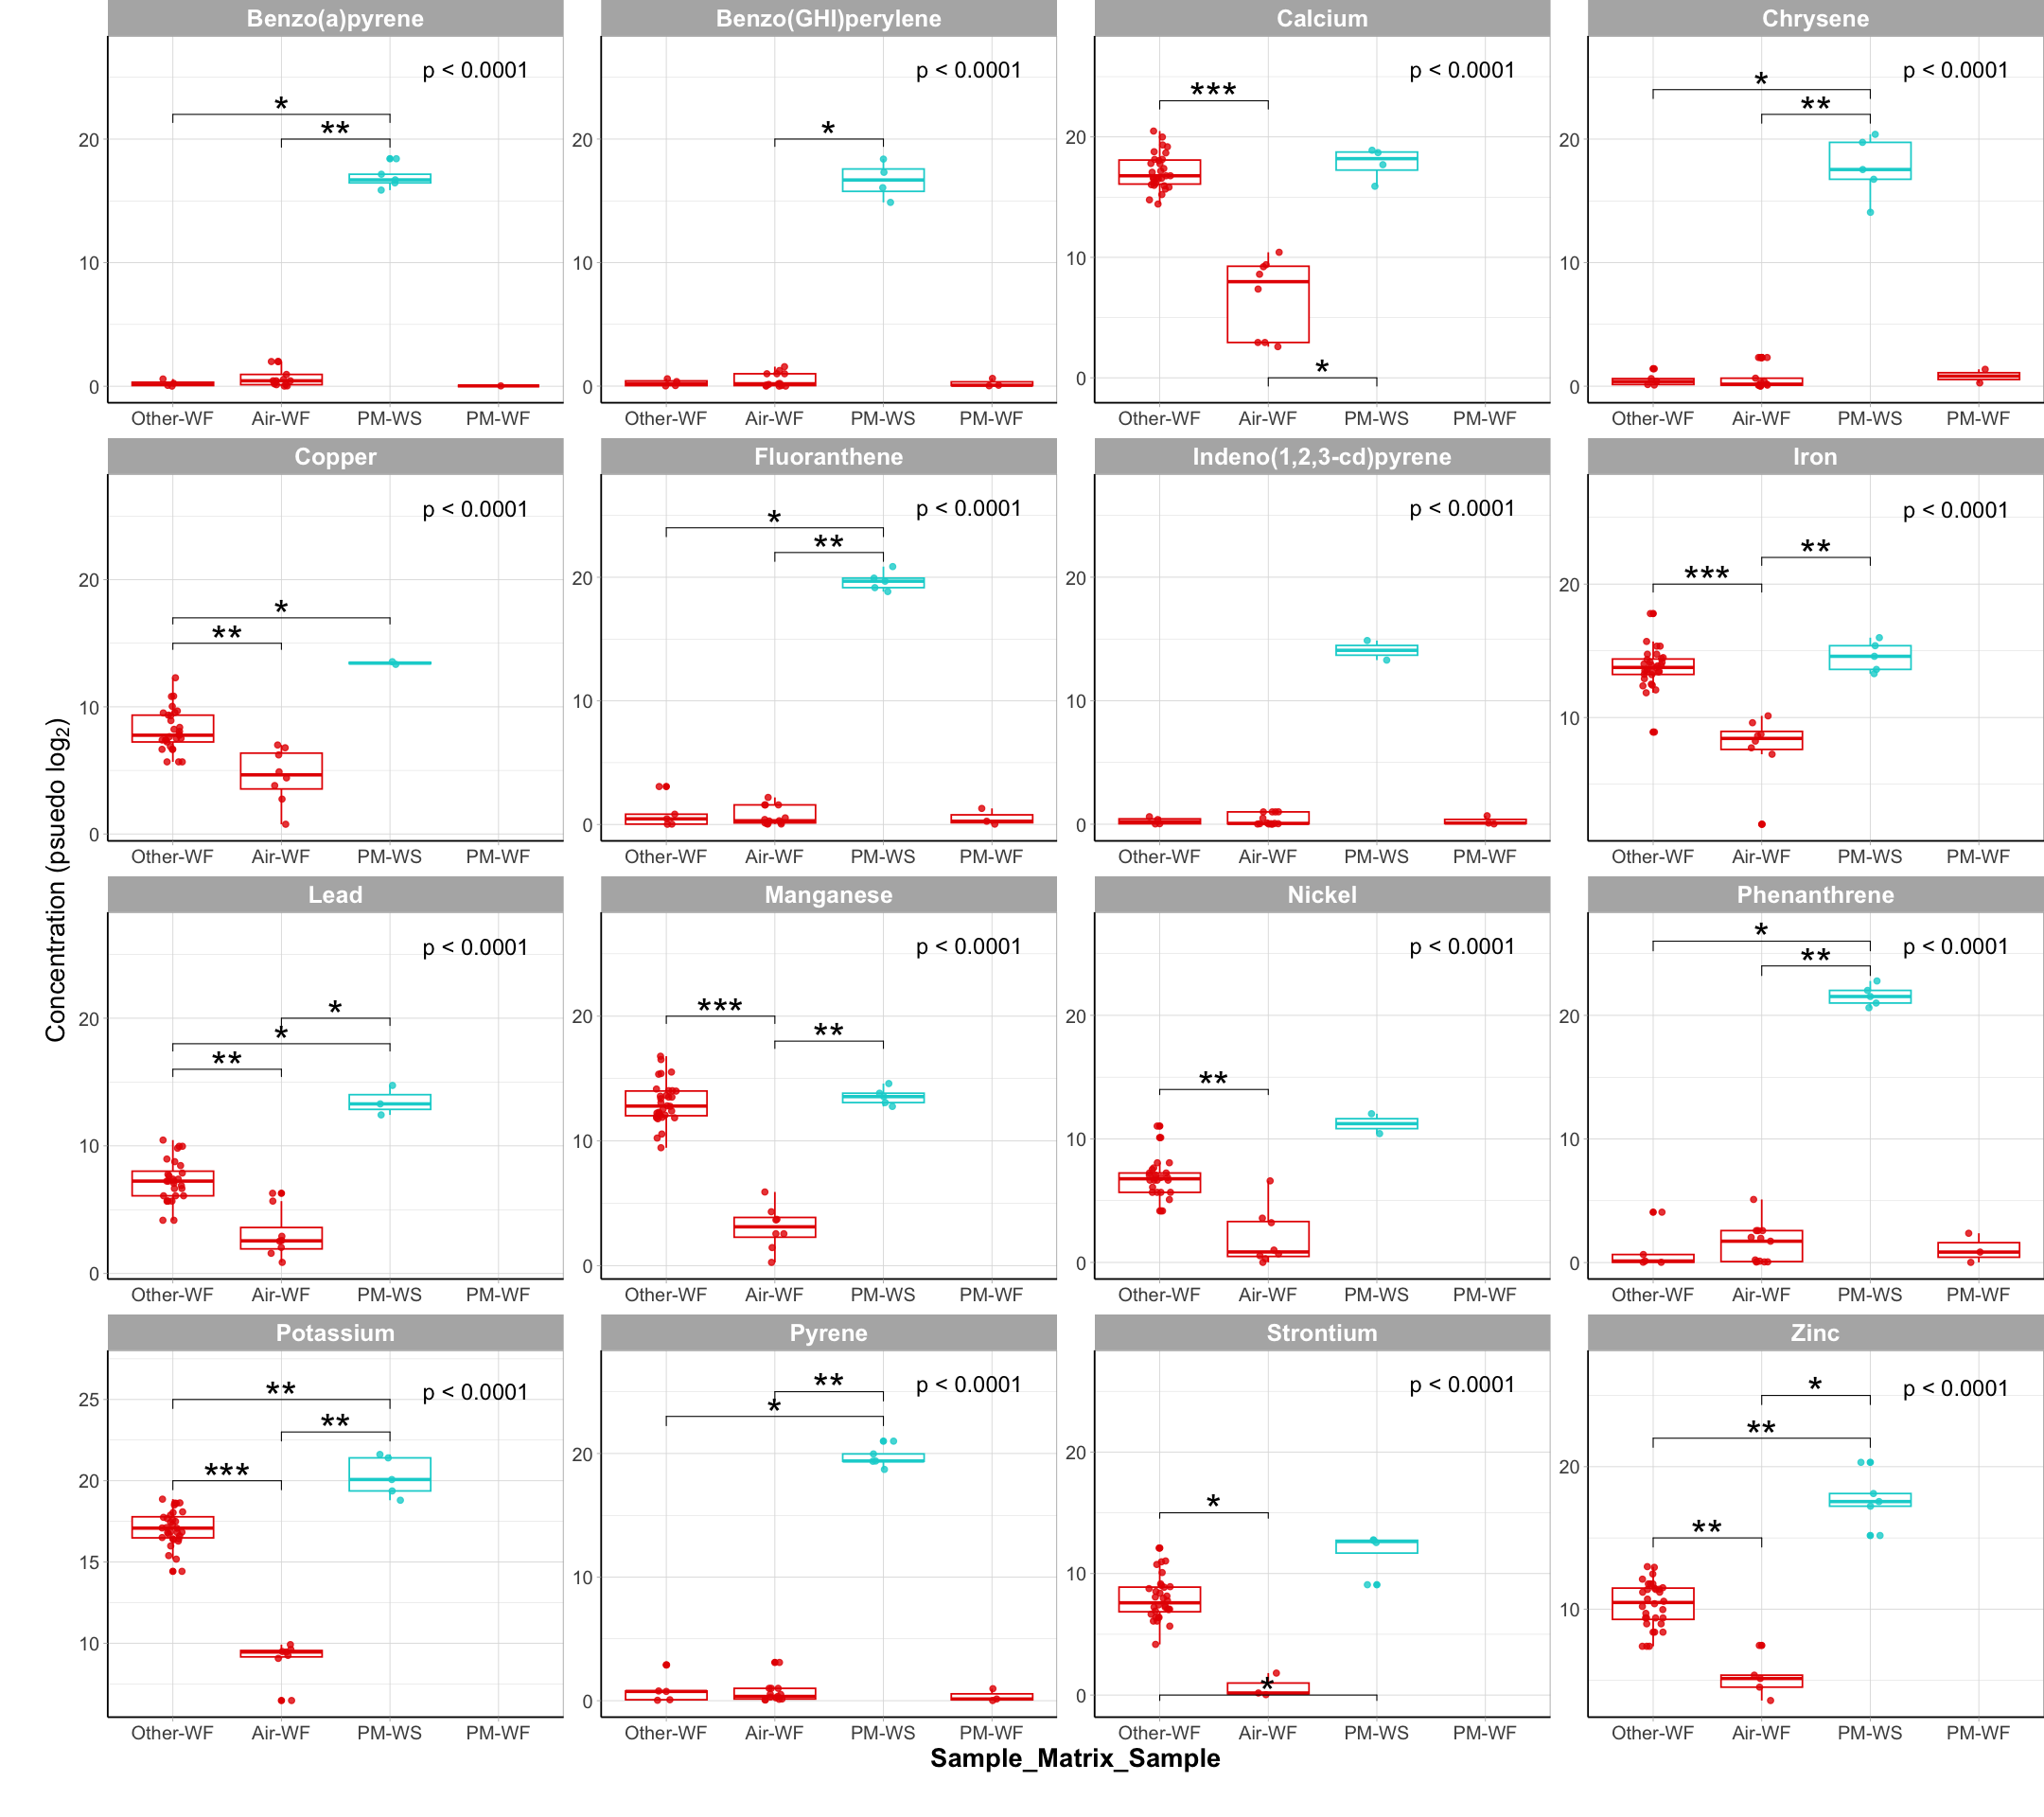

In [20]:
ggplot(data = long_vol_df, aes(x = Sample_Matrix_Sample, y = Value, color = Sample)) + 
  geom_boxplot() + 
  geom_point(position = position_jitter(w = 0.1), alpha = 0.8) + 
  ylim(NA, 27) + # adding more space for p value significance

  # overall anova p value
  stat_anova_test(wid = "Sample_Matrix_Sample", p.adjust.method = "none", label = "p = {p.format}", 
                     label.x.npc = "right", size = 5, label.y = 25, label.x = 3.5) +

  # Adding a p value from a Wilcoxon test
  stat_pvalue_manual(t_test_p_values_sm_vol %>%
                         filter(p.signif != 'ns'), label = "p.signif", size = 9) +

  facet_wrap(~Name, scales = 'free') +  

  theme_light() + 
  theme(axis.line = element_line(colour = "black"), #making x and y axes black
        axis.text = element_text(size = 12), #changing size of x axis labels
        legend.position = 'none', # removes legend
        plot.margin = unit(c(0,0,2,2), "lines"), # adding space at the bottom of the figure
        axis.title = element_text(face = "bold", size = rel(1.5)),
        strip.text.x = element_text(size = 15, face = "bold"), #changes size of facet x axis 
        strip.text.y = element_text(size = 15, face = "bold")) + #changes axis titles

  labs(y = expression("Concentration (psuedo "*log[2]*") ")) + #changing axis labels 
  scale_color_manual(values = c('#e60000', '#00d2d2')) + 

  scale_x_discrete(labels = c("PM-Woodsmoke" = "PM-WS", "Smoke-Wildfire" = "Smoke-WF", "Air-Wildfire" = "Air-WF",
                             "PM-Wildfire" = "PM-WF"))

In [21]:
strata_sm_weight_df = long_weight_df %>%
    # only keeping groups that have at least 2 samples
    group_by(Name, Sample_Matrix_Sample) %>%
    filter(sum(!is.na(Value)) >= 2) %>%
    ungroup()

t_test_p_values_sm_weight = compare_means(Value ~ Sample_Matrix_Sample, data = strata_sm_weight_df, 
                                         method = "wilcox.test", p.adjust.method = 'fdr', group.by = "Name") %>%

    # basing the p.signif off of adjusted p values
    mutate(p.signif = ifelse(p.adj < 0.0001, '****', 
                             ifelse(p.adj >= 0.0001 & p.adj < 0.001, '***',
                                   ifelse(p.adj >= 0.001 & p.adj < 0.01, '**',
                                         ifelse(p.adj >= 0.01 & p.adj < 0.05, '*', 
                                                    'ns'))))) %>%
    # manually adding the y position
    mutate(y.position = c(14, 0, 0, 0, 18, rep(1.3, times = 5), 15, 17, rep(1.3, times = 7), 19, 21, 0, 0, 0, 14,
                          rep(1.3, times = 6), 18, rep(1.3, times = 9), 20, 0, 18, 16, 14, 16, 0, 15, 17, 0, 0, 
                          16, 0, 15, 13, 15, 0, 15, 17, 13, 0, 15, 0, 0, 12, 10))


head(t_test_p_values_sm_weight)

Name,.y.,group1,group2,p,p.adj,p.format,p.signif,method,y.position
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>
Chromium,Value,NA-Woodsmoke,PM-Woodsmoke,0.007090301,0.031,0.00709,*,Wilcoxon,14.0
Chromium,Value,NA-Woodsmoke,PM-Wildfire,0.038095238,0.079,0.03810,ns,Wilcoxon,0.0
Chromium,Value,NA-Woodsmoke,Ash-Wildfire,0.148179326,0.210,0.14818,ns,Wilcoxon,0.0
Chromium,Value,PM-Woodsmoke,PM-Wildfire,0.145414801,0.210,0.14541,ns,Wilcoxon,0.0
Chromium,Value,PM-Woodsmoke,Ash-Wildfire,0.005603701,0.027,0.00560,*,Wilcoxon,18.0
Chromium,Value,PM-Wildfire,Ash-Wildfire,0.397599925,0.460,0.39760,ns,Wilcoxon,1.3


Warning message:
“Removed 816 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 816 rows containing non-finite outside the scale range
(`stat_compare_multiple_means()`).”
Warning message:
“Removed 816 rows containing missing values or values outside the scale range
(`geom_point()`).”


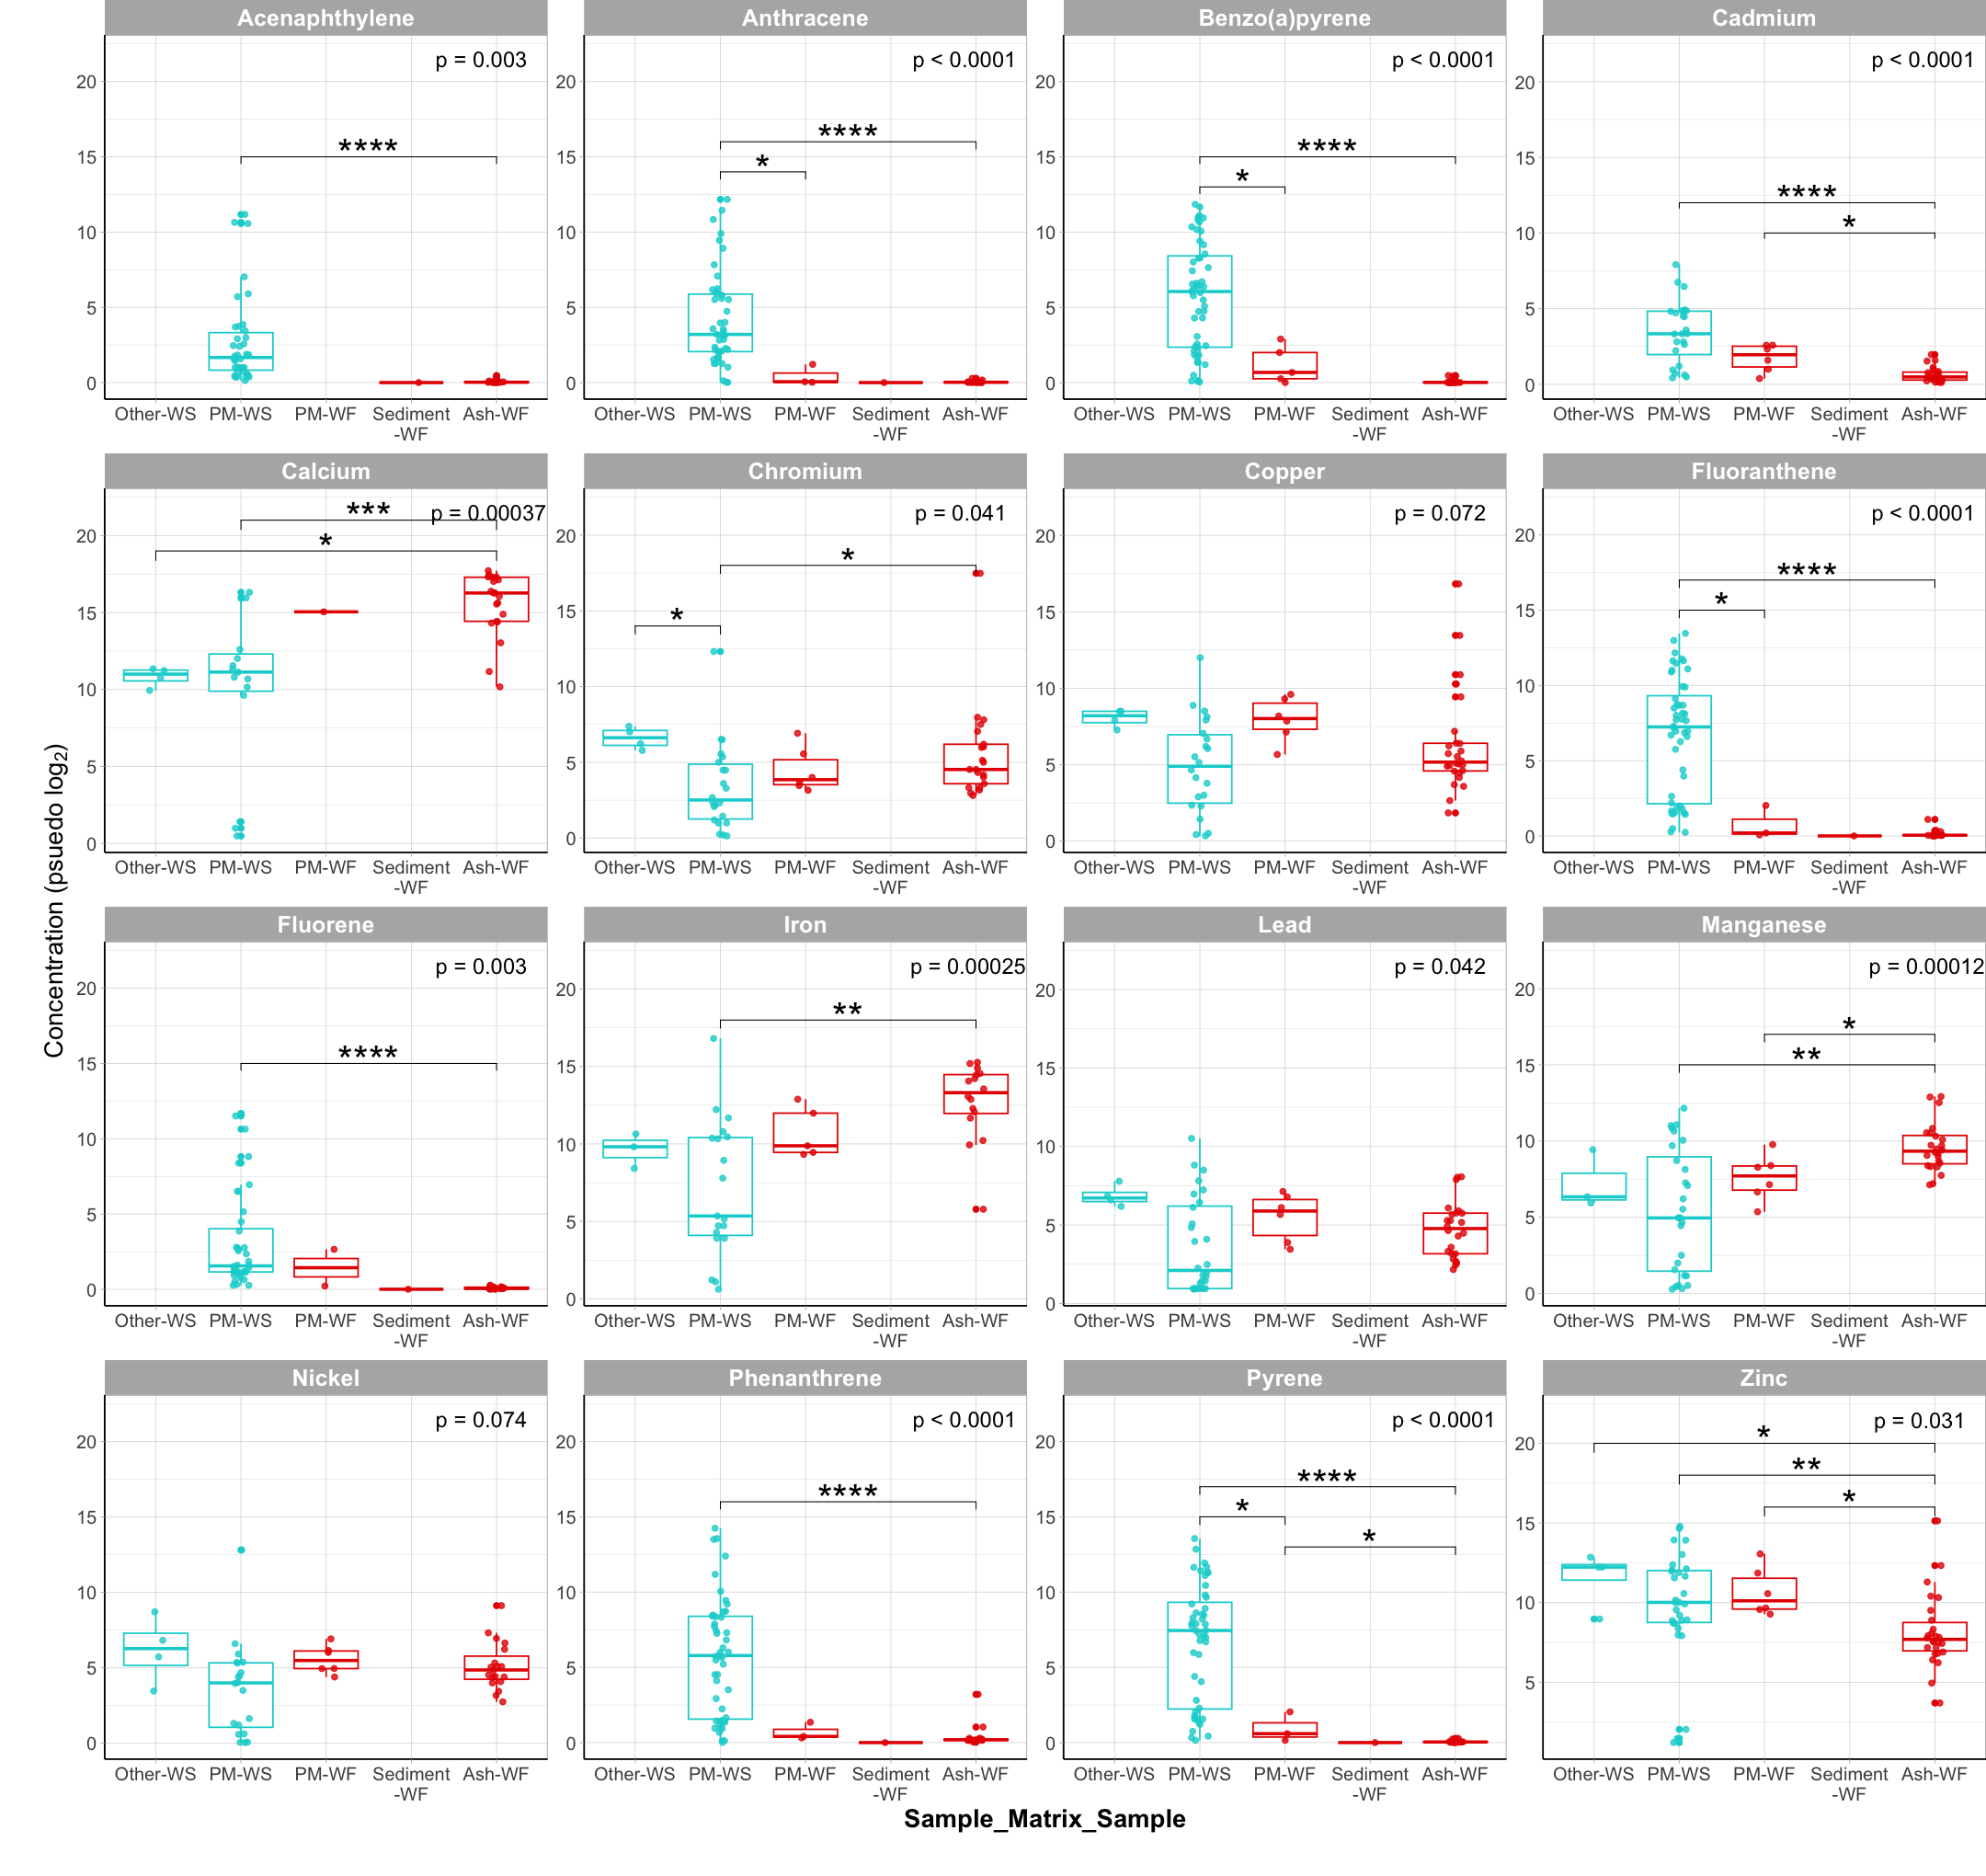

In [22]:
options(repr.plot.width=18, repr.plot.height=17) #changing size
ggplot(data = long_weight_df, aes(x = Sample_Matrix_Sample, y = Value, color = Sample)) + 
  geom_boxplot() + 
  geom_point(position = position_jitter(w = 0.1), alpha = 0.8) + 
  ylim(NA, 22) + # adding more space for p value significance

  # overall anova p value
  stat_anova_test(wid = "Sample_Matrix_Sample", p.adjust.method = "none", label = "p = {p.format}", 
                     label.x.npc = "right", size = 5, label.y = 21, label.x = 4.5) +

  # Adding a p value from a Wilcoxon test
  stat_pvalue_manual(t_test_p_values_sm_weight %>%
                         filter(p.signif != 'ns', Name != "Copper"), label = "p.signif", size = 9) +

  facet_wrap(~Name, scales = 'free') +  

  theme_light() + 
  theme(axis.line = element_line(colour = "black"), #making x and y axes black
        axis.text = element_text(size = 12), #changing size of x axis labels
        legend.position = 'none', # removes legend
        plot.margin = unit(c(0,0,2,2), "lines"), # adding space at the bottom of the figure
        axis.title = element_text(face = "bold", size = rel(1.5)),
        strip.text.x = element_text(size = 15, face = "bold"), #changes size of facet x axis 
        strip.text.y = element_text(size = 15, face = "bold")) + #changes axis titles

  labs(y = expression("Concentration (psuedo "*log[2]*") ")) + #changing axis labels 
  scale_color_manual(values = c('#e60000', '#00d2d2')) + 

  scale_x_discrete(labels = c("PM-Woodsmoke" = "PM-WS", "Smoke-Wildfire" = "Smoke-WF", "NA-Woodsmoke" = "Other-WS",
                             "PM-Wildfire" = "PM-WF", "Sediment-Wildfire" = "Sediment\n-WF", "Ash-Wildfire" = "Ash-WF"))

In [23]:
# # exporting figures
# ggsave(vol_boxplots, 
#        filename = 'Boxplots1.pdf',
#        path = Output,
#        width = 18, height = 16)

# ggsave(weight_boxplots, 
#        filename = 'Boxplots2.pdf',
#        path = Output,
#        width = 18, height = 16)